# The tsib energy system framework

`tsib.energysystem` is a generic, component-based optimization framework which replaces the
former monolithic `Building5R1C` model. Components are plugged onto carrier-specific **buses**
and optimized jointly in **one** MILP:

| Building block | Purpose |
|---|---|
| `EnergySystemModel` | orchestrator: builds one pyomo block per component, bus balances, objective |
| `Bus` / `Port` | generic energy balance nodes - no component needs to know any other |
| `ThermalZone5R1C` | the 5R1C building physics (DIN EN ISO 13790) with free temperature states |
| `ElectricalStorage` / `ThermalStorage` | generic storage (EV-ready interface) |
| `PVGenerator`, `GridConnection`, `FixedDemand` | supply, market and demand components |
| `ContinuousInvestment` / `DiscreteOptionInvestment` | optional, composable investment decisions |

**The key architectural idea:** the building's comfort temperature band and its thermal mass are
themselves a *flexibility resource* - structurally equivalent to a thermal storage. That is why the
5R1C zone stays inside the same MILP as storages, PV and prices instead of being reduced to a fixed
heat load time series. This notebook demonstrates exactly that.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tsib
import os
os.environ["SOLVER"] = "highs"

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

## 1. Parameterize a building

As before, a building is parameterized from the TABULA/EPISCOPE archetype database plus DWD test
reference year (TRY) weather, and the occupancy/electricity profiles are simulated with the
CREST-derived `tsorb` model.

In [2]:
import os
import tsib.data

# TABULA archetype: single family house, construction period 1969-1978
building_set = pd.read_csv(
    os.path.join(tsib.data.PATH, "episcope", "tabula_DE_wPersons.csv"),
    header=0, index_col=0,
)
ID = building_set.index[24]
print("Archetype:", ID)

try_data, loc = tsib.readTRY(try_num=4)

bdgcfg = tsib.BuildingConfiguration({
    "ID": ID,
    "weatherData": try_data,
    "weatherID": "TRY_4",
    "refurbishment": False,
    "nightReduction": False,
    "occControl": False,
    "capControl": True,          # smart thermostat -> full comfort band usable
    "n_persons": 2,
    "comfortT_lb": 21.0,
    "comfortT_ub": 23.0,
    "roofOrientation": 0.0,
    "longitude": loc["longitude"],
    "latitude": loc["latitude"],
})
bdg = tsib.Building(configurator=bdgcfg)

# simulate occupancy, internal gains and electric device load
bdg.getOccupancy()

print("Heated reference area:", bdg.cfg["A_ref"], "m²")
print("Design heat load:", round(bdg.zone_config.calcDesignHeatLoad(), 1), "kW")

Archetype: DE.N.SFH.06.Gen.ReEx.001.001
Heated reference area: 173.25 m²
Design heat load: 20.2 kW


/home/phillipschlicht/Sonstiges/fzj/tsib/tsib/buildingconfig.py:304: UserWarning: Keyword ID is not used for the building parameterization.

  warnings.warn('Keyword ' + str(remaining_kwg) + ' is not used for the building parameterization.\n')


## 2. Classic heat load simulation

`Building.getHeatLoad()` works as before - internally it now composes an `EnergySystemModel`
holding a single `ThermalZone5R1C` and solves it. The solved model stays accessible via
`Building.energysystem`.

/home/phillipschlicht/Sonstiges/fzj/tsib/tsib/energysystem/components/thermalzone5r1c.py:808: UserWarning: Maximal heat load exceeded by 7.505 kW
  warnings.warn(
/home/phillipschlicht/Sonstiges/fzj/tsib/tsib/energysystem/components/thermalzone5r1c.py:808: UserWarning: Maximal heat load exceeded by 7.505 kW
  warnings.warn(


Annual heat demand: 218.7 kWh/m²/a


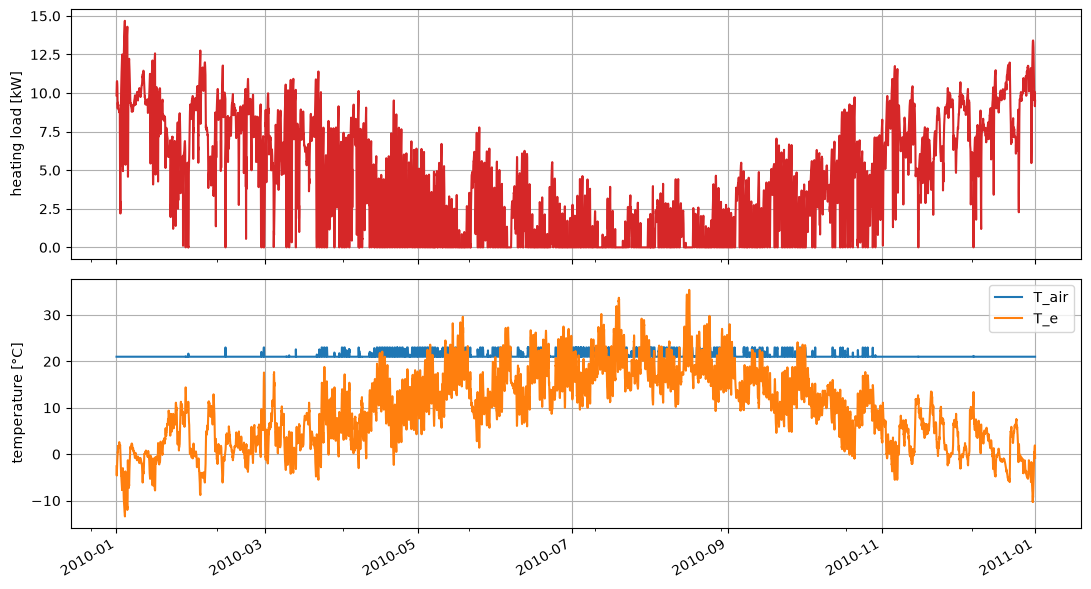

In [3]:
heat = bdg.getHeatLoad()

zone_ts = bdg.energysystem.results("thermalzone")["timeseries"]

week = slice("2010-01-01", "2010-12-31")
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(11, 6))
zone_ts.loc[week, "Heating Load"].plot(ax=ax1, color="tab:red")
ax1.set_ylabel("heating load [kW]")
zone_ts.loc[week, ["T_air", "T_e"]].plot(ax=ax2)
ax2.set_ylabel("temperature [°C]")
plt.tight_layout()

print("Annual heat demand:", round(heat["Heating Load"].sum() / bdg.cfg["A_ref"], 1), "kWh/m²/a")

## 3. Thermal mass as a flexibility resource

Now the same zone is coupled via a **heat bus** to a `GridConnection` with a time-varying heat
price (cheap night, expensive evening peak) and a small hot water tank - all dispatched in **one**
solve. Because the temperature states of the zone remain free decision variables, the optimizer can
pre-heat the building mass within the comfort band before the price spike.

In [4]:
# one January week of the building configuration
cfg = dict(bdg.cfg)
n = 168
cfg["weather"] = cfg["weather"].iloc[:n]
for key in ["Q_ig", "occ_nothome", "occ_sleeping", "elecLoad"]:
    cfg[key] = cfg[key][:n] if isinstance(cfg[key], np.ndarray) else cfg[key].iloc[:n]

index = cfg["weather"].index
hour = pd.DatetimeIndex(index).hour
heat_price = pd.Series(
    np.where((hour >= 17) & (hour <= 21), 0.30,        # evening peak
             np.where(hour < 6, 0.02, 0.10)),          # cheap night / day
    index=index,
)


def solve_heat_system(comfort_ub, with_tank=True):
    model = tsib.EnergySystemModel(index, wacc=cfg["WACC"])
    heat_bus = model.add(tsib.Bus("heat"))
    cfg_run = dict(cfg, comfortT_ub=comfort_ub)
    model.add(tsib.ThermalZone5R1C("zone", cfg_run, heat_bus=heat_bus, refurbishment=False))
    model.add(tsib.GridConnection("heat_grid", heat_bus, import_price=heat_price))
    if with_tank:
        model.add(tsib.ThermalStorage("tank", heat_bus, capacity=30.0,
                                      charge_efficiency=0.98, discharge_efficiency=0.98,
                                      standby_loss_kW=0.05))
    model.solve(tee=False)
    return model


flexible = solve_heat_system(comfort_ub=22.0, with_tank=False)
rigid = solve_heat_system(comfort_ub=21.0 + 1e-6, with_tank=False)   # comfort band collapsed -> no flexibility

print("Heat cost with flexibility:   ", round(flexible.objective_value, 2), "EUR")
print("Heat cost without flexibility:", round(rigid.objective_value, 2), "EUR")
print("Savings:", round(100 * (1 - flexible.objective_value / rigid.objective_value), 1), "%")

Heat cost with flexibility:    193.2 EUR
Heat cost without flexibility: 197.4 EUR
Savings: 2.1 %


In [5]:
# ts = flexible.results("zone")["timeseries"]
# tank = flexible.results("tank")
# imports = flexible.results("heat_grid")["import"]

# fig, axes = plt.subplots(4, 1, sharex=True, figsize=(11, 10))
# axes[0].step(index, heat_price.values, color="tab:purple", where="post")
# axes[0].set_ylabel("heat price\n[EUR/kWh]")
# axes[1].step(index, imports.values, color="tab:red", where="post", label="grid import")
# axes[1].step(index, ts["Heating Load"].values, color="tab:orange", where="post", label="zone heating")
# axes[1].legend(); axes[1].set_ylabel("heat flow [kW]")
# axes[2].plot(index, ts["T_air"].values, label="T_air")
# axes[2].plot(index, ts["T_m"].values, label="T_m (thermal mass)")
# axes[2].axhline(20.0, color="grey", ls="--", lw=0.8)
# axes[2].legend(); axes[2].set_ylabel("temperature [°C]")
# axes[3].plot(index, tank["soc"].values, color="tab:green")
# axes[3].set_ylabel("tank SOC [kWh]")
# plt.tight_layout()

The pattern is clearly visible: during the cheap night hours the optimizer buys heat, loads the
tank **and raises the building mass temperature** above the comfort minimum; through the expensive
evening peak the zone then coasts on its own thermal mass and the tank - grid import drops to
(almost) zero. This behavior is exactly what is lost when a building model is solved standalone and
handed to a dispatch optimization as a fixed load profile.

## 4. PV, battery and household load on the electricity bus

The same framework composes the electric side: the tsorb household load, a rooftop PV plant
(specific yield from `tsib.simPhotovoltaic`) whose capacity is a **continuous investment
decision**, a battery and the grid with import price and feed-in remuneration.

Optimal PV capacity:      10.0 kWp
Optimal battery capacity: 2.06 kWh


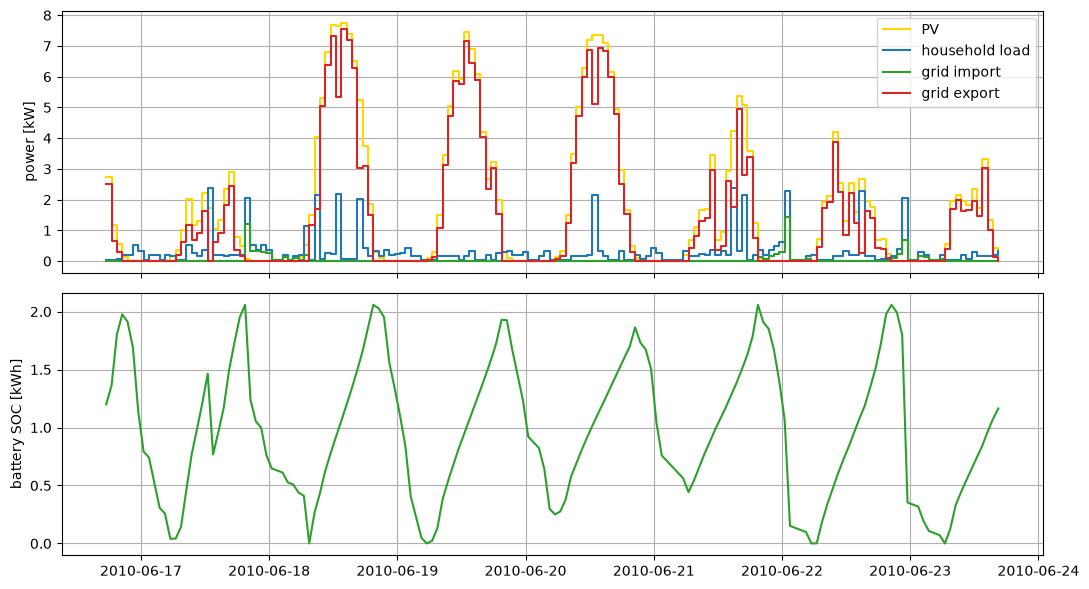

In [6]:
# specific PV yield [kW/kWp] for the same summer week
tmy = tsib.TRY2TMY(bdg.cfg["weather"])
pv_yield, _ = tsib.simPhotovoltaic(
    tmy, surface_tilt=35.0, surface_azimuth=180.0,
    latitude=loc["latitude"], longitude=loc["longitude"], losses=0.1,
)

summer = slice(4000, 4000 + 168)
idx_summer = bdg.cfg["weather"].index[summer]
elec_load = bdg.cfg["elecLoad"].iloc[summer]

model = tsib.EnergySystemModel(idx_summer, wacc=bdg.cfg["WACC"])
elec_bus = model.add(tsib.Bus("elec", carrier="electricity"))
model.add(tsib.FixedDemand("household", elec_bus, elec_load))
model.add(tsib.GridConnection("grid", elec_bus, import_price=0.32, export_price=0.05))
model.add(tsib.PVGenerator(
    "pv", elec_bus, pv_yield.iloc[summer],
    capacity=tsib.ContinuousInvestment(capex_per_unit=900.0, lifetime=25,
                                       opex_fix_share=0.015, max_capacity=10.0),
))
model.add(tsib.ElectricalStorage(
    "battery", elec_bus,
    capacity=tsib.ContinuousInvestment(capex_per_unit=600.0, lifetime=15, max_capacity=20.0),
    charge_efficiency=0.95, discharge_efficiency=0.95,
))
model.solve(tee=False)

res = model.results()
print("Optimal PV capacity:     ", round(res["pv"]["capacity"], 2), "kWp")
print("Optimal battery capacity:", round(res["battery"]["capacity"], 2), "kWh")

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(11, 6))
ax1.step(idx_summer, res["pv"]["generation"].values, color="gold", where="post", label="PV")
ax1.step(idx_summer, elec_load.values, color="tab:blue", where="post", label="household load")
ax1.step(idx_summer, res["grid"]["import"].values, color="tab:green", where="post", label="grid import")
ax1.step(idx_summer, res["grid"]["export"].values, color="tab:red", where="post", label="grid export")
ax1.legend(); ax1.set_ylabel("power [kW]")
ax2.plot(idx_summer, res["battery"]["soc"].values, color="tab:green")
ax2.set_ylabel("battery SOC [kWh]")
plt.tight_layout()

## 5. Envelope refurbishment as a discrete investment decision

Attaching `DiscreteOptionInvestment`s to the zone turns the envelope (walls, roof, floor, windows,
ventilation) into "choose exactly one option per element" MILP decisions, co-optimized with
operation. Without attached investment (all sections above) **zero** binary variables are created.

In [7]:
# a few winter days are enough for the demo MILP (investment cost is
# scaled with the covered year fraction)
cfg_invest = {k: (v[:72] if isinstance(v, np.ndarray)
                  else v.iloc[:72] if isinstance(v, (pd.Series, pd.DataFrame)) and k != "weather"
                  else v)
              for k, v in dict(bdg.cfg).items()}
cfg_invest["weather"] = bdg.cfg["weather"].iloc[:72]

model = tsib.EnergySystemModel(cfg_invest["weather"].index, wacc=cfg_invest["WACC"])
zone = model.add(tsib.ThermalZone5R1C("zone", cfg_invest, refurbishment=True))
model.solve(tee=False)

block = model.pyomo_model.zone
chosen = {element: inv.selected_option(block)
          for element, inv in zone.envelope_investments.items()}
print("Chosen refurbishment options:")
for element, option in chosen.items():
    print(f"  {element:12s} -> {option}")
print("Design heat load with refurbishment:",
      round(model.results('zone')['static']['Capacity'], 1), "kW",
      "(before:", round(bdg.zone_config.calcDesignHeatLoad(), 1), "kW)")

Chosen refurbishment options:
  Walls        -> Enev 2016
  Roof         -> Nothing
  Floor        -> Enev 2016
  Windows      -> Future
  Ventilation  -> Nothing
Design heat load with refurbishment: 10.0 kW (before: 20.2 kW)


## 6. Outlook

* **EV battery**: `StorageComponent` already accepts time series charge/discharge power limits and
  has a protected `_external_energy_delta` hook - an `EVBattery` subclass only needs to feed an
  availability profile and the driving energy withdrawal.
* **Myopic / rolling horizon**: `MyopicStrategy` and `RollingHorizonStrategy` are documented
  interface stubs; `TimeIndex.slice()` and the `initial_state()`/`final_state()` hooks they need
  already exist. Free investment decisions are rejected for such strategies (fail-fast guard) -
  the intended pattern is to freeze a perfect-foresight investment first.
* **Heat pump dispatch component** coupling the electricity and heat bus is the natural next
  extension of the component family.

In [8]:
cfg = dict(bdg.cfg)
n = 168
cfg["weather"] = cfg["weather"].iloc[:n]
for key in ["Q_ig", "occ_nothome", "occ_sleeping", "elecLoad"]:
    cfg[key] = cfg[key][:n] if isinstance(cfg[key], np.ndarray) else cfg[key].iloc[:n]

index = cfg["weather"].index
hour = pd.DatetimeIndex(index).hour
elec_price = pd.Series(
    np.where((hour >= 17) & (hour <= 21), 0.30,        # evening peak
             np.where(hour < 6, 0.02, 0.10)),          # cheap night / day
    index=index,
)

def solve_heat_system(comfort_ub):
    cfg_run = dict(cfg, comfortT_ub=comfort_ub)
    model = tsib.EnergySystemModel(index, wacc=cfg["WACC"])

    heat_bus = model.add(tsib.Bus("heat"))
    elec_bus = model.add(tsib.Bus("elec"))

    model.add(tsib.ThermalZone5R1C("zone", cfg_run, heat_bus=heat_bus, refurbishment=False))
    model.add(tsib.GridConnection("elec_grid", elec_bus, import_price=elec_price))
    model.add(
        tsib.HeatPump(
            name="heat_pump", 
            elec_bus=elec_bus, 
            heat_bus=heat_bus, 
            cop=3,
            capacity=tsib.ContinuousInvestment(
                capex_per_unit=900.0, lifetime=25,
                opex_fix_share=0.015,
            )
        )
    )

    model.solve(tee=False)
    return model


flexible = solve_heat_system(comfort_ub=22.0)
rigid = solve_heat_system(comfort_ub=21.0 + 1e-6)   # comfort band collapsed -> no flexibility

print("Heat cost with flexibility:   ", round(flexible.objective_value, 2), "EUR")
print("Heat cost without flexibility:", round(rigid.objective_value, 2), "EUR")
print("Savings:", round(100 * (1 - flexible.objective_value / rigid.objective_value), 1), "%")


Heat cost with flexibility:    82.27 EUR
Heat cost without flexibility: 84.15 EUR
Savings: 2.2 %


## 7. Full workflow: a complete building energy system

Everything above, end to end and over a **full year**: TABULA configuration -> stochastic
occupancy -> renewable potentials (PV yield and heat pump COP) -> one energy system model that
sizes PV, heat pump, battery and heat tank *and* dispatches them against a time-varying price,
all in a single solve.

Two things keep the pipeline lean. `getRenewables()` returns its profiles on the same index as
`cfg["weather"]`, so **no index juggling is needed** - the series are handed to the components
as they are. And because every investment here is a `ContinuousInvestment` (no discrete catalog,
`refurbishment=False`), the model has **no binaries**: the whole year stays an LP and solves in
well under a minute, which a full-year MILP would not.


/home/phillipschlicht/Sonstiges/fzj/tsib/tsib/buildingconfig.py:304: UserWarning: Keyword ID is not used for the building parameterization.

  warnings.warn('Keyword ' + str(remaining_kwg) + ' is not used for the building parameterization.\n')
/home/phillipschlicht/Sonstiges/fzj/tsib/tsib/buildingconfig.py:304: UserWarning: Keyword n_apartments is not used for the building parameterization.

  warnings.warn('Keyword ' + str(remaining_kwg) + ' is not used for the building parameterization.\n')
/home/phillipschlicht/Sonstiges/fzj/tsib/tsib/energysystem/components/thermalzone5r1c.py:808: UserWarning: Maximal heat load exceeded by 4.728 kW
  warnings.warn(


Total annual cost 5104 EUR/a   (sized in the same solve)
  PV          15.00 kWp
  heat pump   11.32 kW_th
  battery      3.73 kWh
  heat tank   59.27 kWh
  grid import 12281 kWh | export 7520 kWh | heat 34568 kWh_th | SPF 2.36


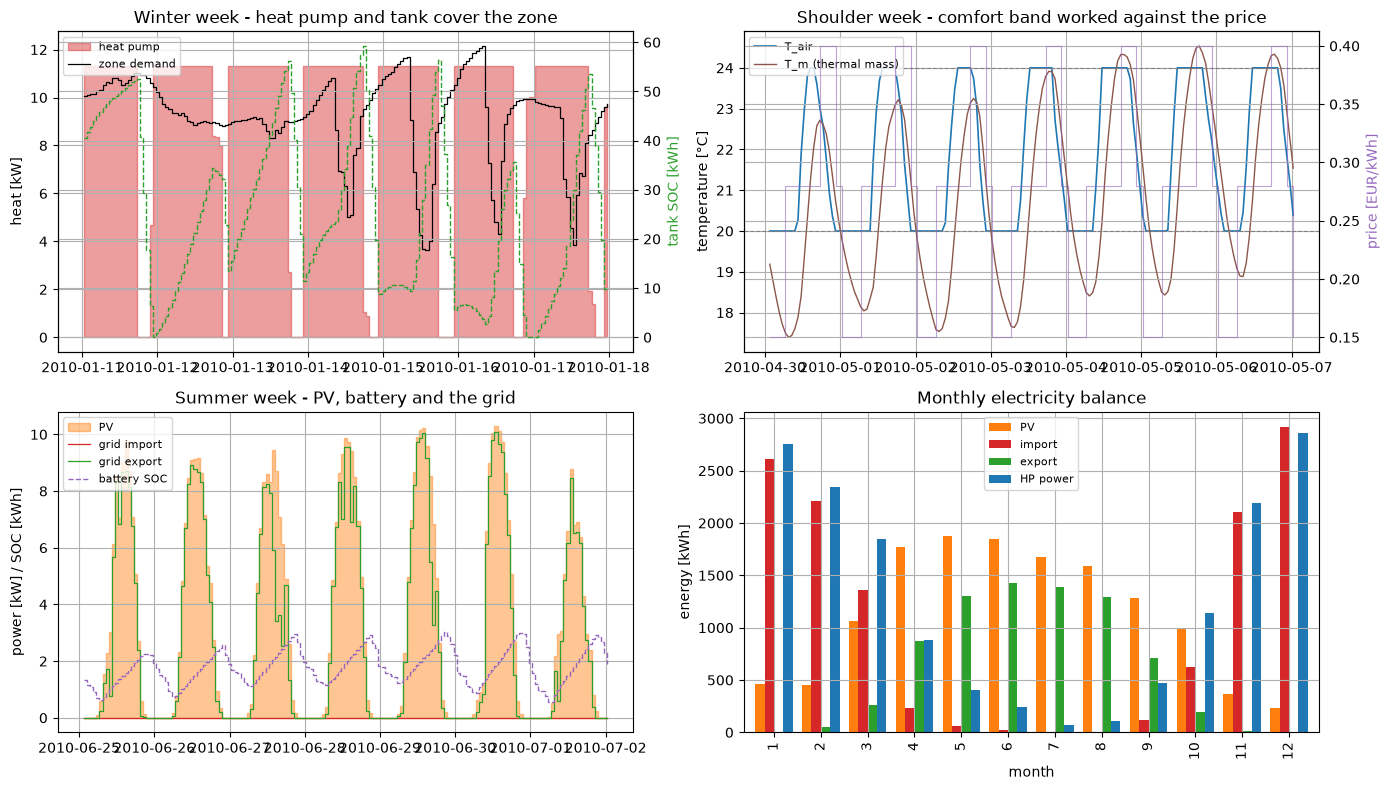

In [ ]:
# 1. configuration
building_set = pd.read_csv(
    os.path.join(tsib.data.PATH, "episcope", "tabula_DE_wPersons.csv"),
    header=0, index_col=0,
)
try_data, loc = tsib.readTRY(try_num=4)
bdg = tsib.Building(configurator=tsib.BuildingConfiguration({
    "ID": building_set.index[24],           # TABULA archetype: SFH 1969-1978
    "weatherData": try_data, "weatherID": "TRY_4",
    "refurbishment": False,                 # envelope fixed -> no binaries, stays an LP
    "capControl": True,                     # smart thermostat -> usable comfort band
    "nightReduction": False, "occControl": False,
    "n_persons": 2, "comfortT_lb": 20.0, "comfortT_ub": 24.0,
    "roofOrientation": 0.0, "n_apartments": 1,
    "longitude": loc["longitude"], "latitude": loc["latitude"],
}))


# 2. occupancy and renewables
occupancy = bdg.getOccupancy()      # stochastic presence -> internal gains + elecLoad
renewables = bdg.getRenewables()    # PV yield [kW/kWp] and heat pump COP [-]

cfg = bdg.cfg
index = cfg["weather"].index        # 8760 h - cfg and renewables share this index
hour = pd.DatetimeIndex(index).hour
price = pd.Series(np.where((hour >= 17) & (hour < 22), 0.40,     # evening peak
                           np.where(hour < 6, 0.15, 0.28)),      # cheap night / day
                  index=index)


# 3. the energy system
inv = tsib.ContinuousInvestment     # continuous -> no binaries, the year stays an LP
model = tsib.EnergySystemModel(index, wacc=cfg["WACC"])

# Add Bus
elec = model.add(tsib.Bus("elec", carrier="electricity"))
heat = model.add(tsib.Bus("heat", carrier="heat"))

# Add Grid
model.add(tsib.GridConnection("grid", elec, import_price=price, export_price=0.08))

# Add Demand
model.add(tsib.ThermalZone5R1C("zone", cfg, heat_bus=heat, refurbishment=False))
model.add(tsib.FixedDemand("household", elec, cfg["elecLoad"]))

# Add Components
model.add(tsib.PVGenerator("pv", elec, renewables["Photovoltaic 1"],
                           capacity=inv(1200.0, 25, opex_fix_share=0.02, max_capacity=15.0)))
model.add(tsib.HeatPump("hp", elec, heat, renewables["Heat pump"],
                        capacity=inv(900.0, 20, opex_fix_share=0.015)))
model.add(tsib.ElectricalStorage("battery", elec,
                                 capacity=inv(400.0, 15, opex_fix_share=0.01)))
model.add(tsib.ThermalStorage("tank", heat, standby_loss_kW=0.05,
                              capacity=inv(25.0, 20, opex_fix_share=0.01)))

model.solve()                       # ONE LP over the whole year (~35 s)


# 4. results
r = model.results()
zone = r["zone"]["timeseries"]
gen, imp, exp = r["pv"]["generation"], r["grid"]["import"], r["grid"]["export"]
print(f"Total annual cost {model.objective_value:.0f} EUR/a   (sized in the same solve)")
for label, val, unit in [("PV", r["pv"]["capacity"], "kWp"), ("heat pump", r["hp"]["capacity"], "kW_th"),
                         ("battery", r["battery"]["capacity"], "kWh"), ("heat tank", r["tank"]["capacity"], "kWh")]:
    print(f"  {label:10s}{val:7.2f} {unit}")
print(f"  grid import {imp.sum():.0f} kWh | export {exp.sum():.0f} kWh | "
      f"heat {zone['Heating Load'].sum():.0f} kWh_th | SPF {r['hp']['heat'].sum()/r['hp']['power'].sum():.2f}")


# 5. plot
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
w = slice(24 * 10, 24 * 17)        # deep winter: heat pump at its limit
sh = slice(24 * 119, 24 * 126)     # shoulder season: heat pump has headroom
s = slice(24 * 175, 24 * 182)      # summer: PV week

# (0,0) winter: where the heat comes from - the heat pump stops in every price peak
ti = index[w]
ax[0, 0].fill_between(ti, r["hp"]["heat"][w], color="tab:red", alpha=.45, step="post", label="heat pump")
ax[0, 0].step(ti, zone["Heating Load"][w], color="k", lw=.9, where="post", label="zone demand")
ax[0, 0].set_ylabel("heat [kW]"); ax[0, 0].legend(loc="upper left", fontsize=8)
axt = ax[0, 0].twinx(); axt.step(ti, r["tank"]["soc"][w], color="tab:green", lw=1, ls="--", where="post")
axt.set_ylabel("tank SOC [kWh]", color="tab:green")
ax[0, 0].set_title("Winter week - heat pump and tank cover the zone")

# (0,1) shoulder season: the comfort band worked against the price
ti = index[sh]
ax[0, 1].plot(ti, zone["T_air"][sh], color="tab:blue", lw=1.2, label="T_air")
ax[0, 1].plot(ti, zone["T_m"][sh], color="tab:brown", lw=1, label="T_m (thermal mass)")
ax[0, 1].axhline(20, color="grey", ls="--", lw=.8); ax[0, 1].axhline(24, color="grey", ls="--", lw=.8)
ax[0, 1].set_ylabel("temperature [°C]"); ax[0, 1].legend(loc="upper left", fontsize=8)
axp = ax[0, 1].twinx(); axp.step(ti, price[sh], color="tab:purple", lw=.8, where="post", alpha=.6)
axp.set_ylabel("price [EUR/kWh]", color="tab:purple")
ax[0, 1].set_title("Shoulder week - comfort band worked against the price")

# (1,0) summer: the electricity side
ti = index[s]
ax[1, 0].fill_between(ti, gen[s], color="tab:orange", alpha=.45, step="post", label="PV")
ax[1, 0].step(ti, imp[s], color="tab:red", lw=.9, where="post", label="grid import")
ax[1, 0].step(ti, exp[s], color="tab:green", lw=.9, where="post", label="grid export")
ax[1, 0].step(ti, r["battery"]["soc"][s], color="tab:purple", lw=1, ls="--", where="post", label="battery SOC")
ax[1, 0].set_ylabel("power [kW] / SOC [kWh]"); ax[1, 0].legend(loc="upper left", fontsize=8)
ax[1, 0].set_title("Summer week - PV, battery and the grid")

# (1,1) the whole year, condensed
mb = pd.DataFrame({"PV": gen.values, "import": imp.values, "export": exp.values,
                   "HP power": r["hp"]["power"].values},
                  index=pd.DatetimeIndex(index).month).groupby(level=0).sum()
mb.plot.bar(ax=ax[1, 1], width=.8, color=["tab:orange", "tab:red", "tab:green", "tab:blue"])
ax[1, 1].set_ylabel("energy [kWh]"); ax[1, 1].set_xlabel("month")
ax[1, 1].set_title("Monthly electricity balance"); ax[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()